In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
FIGURE_DIR = PROJECT_ROOT / 'figures'
FIGURE_DIR.mkdir(exist_ok=True)

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining
Figure directory: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures


In [7]:
theta_a = np.pi - 0.05
theta_b = -np.pi + 0.05

raw_distance = abs(theta_a - theta_b)

point_a = np.array([np.sin(theta_a),np.cos(theta_a)])
point_b = np.array([np.sin(theta_b),np.cos(theta_b)])

periodic_distance = np.linalg.norm(point_a - point_b)

print("theta_a:", theta_a)
print("theta_b:", theta_b)
print("Raw angle distance:", raw_distance)
print("Periodic sin/cos distance:", periodic_distance)

print("\npoint_a [sin(theta_a), cos(theta_a)]:")
print(point_a)

print("\npoint_b [sin(theta_b), cos(theta_b)]:")
print(point_b)

theta_a: 3.0915926535897933
theta_b: -3.0915926535897933
Raw angle distance: 6.183185307179587
Periodic sin/cos distance: 0.09995833854135655

point_a [sin(theta_a), cos(theta_a)]:
[ 0.04997917 -0.99875026]

point_b [sin(theta_b), cos(theta_b)]:
[-0.04997917 -0.99875026]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp8_angle_unit_circle.png


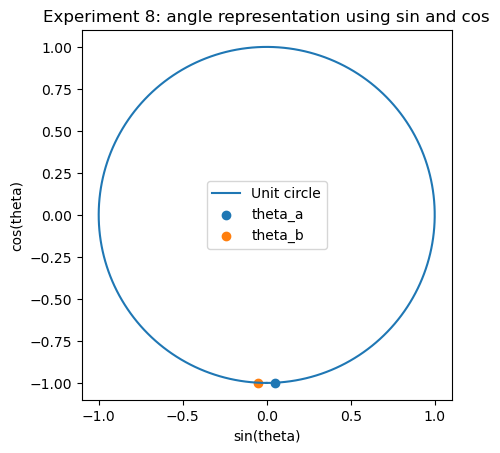

In [9]:
circle_theta = np.linspace(-np.pi, np.pi, 400)

circle_x = np.sin(circle_theta)
circle_y = np.cos(circle_theta)

fig, ax = plt.subplots()

ax.plot(circle_x, circle_y, label="Unit circle")
ax.scatter(point_a[0], point_a[1], label="theta_a")
ax.scatter(point_b[0], point_b[1], label="theta_b")

ax.set_xlabel("sin(theta)")
ax.set_ylabel("cos(theta)")
ax.set_title("Experiment 8: angle representation using sin and cos")
ax.set_aspect("equal")
ax.legend()

fig_path = FIGURE_DIR / "exp8_angle_unit_circle.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [11]:
N = 200
noise_std = 0.08

theta = np.linspace(-np.pi, np.pi, N)

y_clean = 0.7 * np.sin(theta) - 1.2 * np.cos(theta)
epsilon = noise_std * np.random.randn(N)

y = y_clean + epsilon

print("theta shape:", theta.shape)
print("y_clean shape:", y_clean.shape)
print("epsilon shape:", epsilon.shape)
print("y shape:", y.shape)

print("\nFirst 5 theta values:")
print(theta[:5])

print("\nFirst 5 y values:")
print(y[:5])

theta shape: (200,)
y_clean shape: (200,)
epsilon shape: (200,)
y shape: (200,)

First 5 theta values:
[-3.14159265 -3.11001886 -3.07844506 -3.04687127 -3.01529747]

First 5 y values:
[1.34112419 1.2093165  1.23173332 1.30768633 1.25167528]
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp8_periodic_data.png


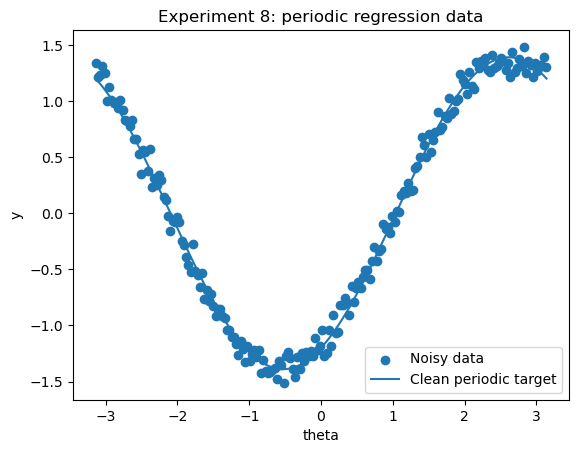

In [13]:
fig, ax = plt.subplots()

ax.scatter(theta, y, label="Noisy data")
ax.plot(theta, y_clean, label="Clean periodic target")

ax.set_xlabel("theta")
ax.set_ylabel("y")
ax.set_title("Experiment 8: periodic regression data")
ax.legend()

fig_path = FIGURE_DIR / "exp8_periodic_data.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [15]:
indices = np.random.permutation(N)

n_train = int(0.6 * N)
n_val = int(0.2 * N)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

theta_train = theta[train_idx]
y_train = y[train_idx]

theta_val = theta[val_idx]
y_val = y[val_idx]

theta_test = theta[test_idx]
y_test = y[test_idx]

print("theta_train shape:", theta_train.shape)
print("y_train shape:", y_train.shape)

print("theta_val shape:", theta_val.shape)
print("y_val shape:", y_val.shape)

print("theta_test shape:", theta_test.shape)
print("y_test shape:", y_test.shape)

theta_train shape: (120,)
y_train shape: (120,)
theta_val shape: (40,)
y_val shape: (40,)
theta_test shape: (40,)
y_test shape: (40,)


In [19]:
def make_raw_angle_features(theta_values):
    """
    Construct raw angle features [theta,1].
    """

    theta_values = np.asarray(theta_values)

    Phi = np.column_stack([theta_values, np.ones(theta_values.shape[0])])

    return Phi

In [21]:
def make_periodic_angle_features(theta_values):
    """
    Construct periodic angle features [sin(theta), cos(theta), 1].
    """
    theta_values = np.asarray(theta_values)

    Phi = np.column_stack([
        np.sin(theta_values),
        np.cos(theta_values),
        np.ones(theta_values.shape[0])
    ])

    return Phi

In [23]:
Phi_raw_demo = make_raw_angle_features(theta_train)
Phi_periodic_demo = make_periodic_angle_features(theta_train)

print("Phi_raw_demo shape:", Phi_raw_demo.shape)
print("Phi_periodic_demo shape:", Phi_periodic_demo.shape)

print("\nFirst 5 raw features:")
print(Phi_raw_demo[:5])

print("\nFirst 5 periodic features:")
print(Phi_periodic_demo[:5])

Phi_raw_demo shape: (120, 2)
Phi_periodic_demo shape: (120, 3)

First 5 raw features:
[[-2.35224777  1.        ]
 [ 3.11001886  1.        ]
 [ 1.34188631  1.        ]
 [ 1.97336222  1.        ]
 [-2.54169054  1.        ]]

First 5 periodic features:
[[-0.70989202 -0.70431053  1.        ]
 [ 0.03156855 -0.99950159  1.        ]
 [ 0.97391431  0.22691611  1.        ]
 [ 0.92005876 -0.3917804   1.        ]
 [-0.56456168 -0.82539088  1.        ]]


In [25]:
def mse(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2)

In [27]:
Phi_raw_train = make_raw_angle_features(theta_train)
Phi_raw_val = make_raw_angle_features(theta_val)
Phi_raw_test = make_raw_angle_features(theta_test)

Phi_periodic_train = make_periodic_angle_features(theta_train)
Phi_periodic_val = make_periodic_angle_features(theta_val)
Phi_periodic_test = make_periodic_angle_features(theta_test)

raw_params, raw_residuals, raw_rank, raw_singular_values = np.linalg.lstsq(
    Phi_raw_train,
    y_train,
    rcond=None
)

periodic_params, periodic_residuals, periodic_rank, periodic_singular_values = np.linalg.lstsq(
    Phi_periodic_train,
    y_train,
    rcond=None
)

print("raw_params shape:", raw_params.shape)
print("periodic_params shape:", periodic_params.shape)

print("\nraw_params:")
print(raw_params)

print("\nperiodic_params:")
print(periodic_params)

print("\nExpected periodic params approximately:")
print("[0.7, -1.2, 0.0]")

raw_params shape: (2,)
periodic_params shape: (3,)

raw_params:
[0.27300806 0.01839697]

periodic_params:
[ 0.7090867  -1.18322058  0.0023189 ]

Expected periodic params approximately:
[0.7, -1.2, 0.0]


In [29]:
y_pred_raw_train = Phi_raw_train @ raw_params
y_pred_raw_val = Phi_raw_val @ raw_params
y_pred_raw_test = Phi_raw_test @ raw_params

y_pred_periodic_train = Phi_periodic_train @ periodic_params
y_pred_periodic_val = Phi_periodic_val @ periodic_params
y_pred_periodic_test = Phi_periodic_test @ periodic_params

raw_train_mse = mse(y_train, y_pred_raw_train)
raw_val_mse = mse(y_val, y_pred_raw_val)
raw_test_mse = mse(y_test, y_pred_raw_test)

periodic_train_mse = mse(y_train, y_pred_periodic_train)
periodic_val_mse = mse(y_val, y_pred_periodic_val)
periodic_test_mse = mse(y_test, y_pred_periodic_test)

print("Raw angle model MSE:")
print("Train MSE:", raw_train_mse)
print("Validation MSE:", raw_val_mse)
print("Test MSE:", raw_test_mse)

print("\nPeriodic sin/cos model MSE:")
print("Train MSE:", periodic_train_mse)
print("Validation MSE:", periodic_val_mse)
print("Test MSE:", periodic_test_mse)

Raw angle model MSE:
Train MSE: 0.7542963799787376
Validation MSE: 1.081252867850804
Test MSE: 0.8773532386686466

Periodic sin/cos model MSE:
Train MSE: 0.005761775581859696
Validation MSE: 0.007733069919665503
Test MSE: 0.008486667324317132


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp8_raw_vs_periodic_fit.png


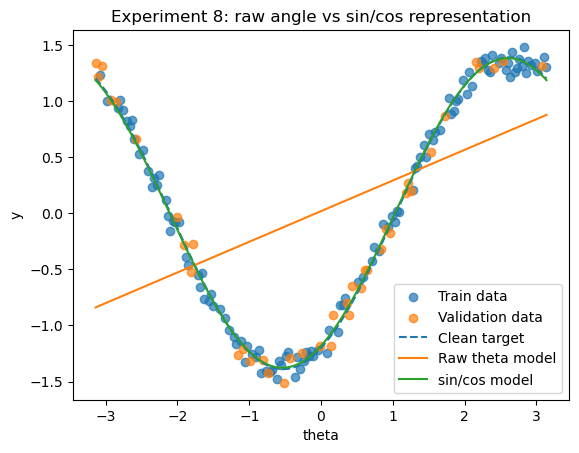

In [31]:
theta_plot = np.linspace(-np.pi, np.pi, 400)

Phi_raw_plot = make_raw_angle_features(theta_plot)
Phi_periodic_plot = make_periodic_angle_features(theta_plot)

y_raw_plot = Phi_raw_plot @ raw_params
y_periodic_plot = Phi_periodic_plot @ periodic_params

y_clean_plot = 0.7 * np.sin(theta_plot) - 1.2 * np.cos(theta_plot)

fig, ax = plt.subplots()

ax.scatter(theta_train, y_train, label="Train data", alpha=0.7)
ax.scatter(theta_val, y_val, label="Validation data", alpha=0.7)

ax.plot(theta_plot, y_clean_plot, linestyle="--", label="Clean target")
ax.plot(theta_plot, y_raw_plot, label="Raw theta model")
ax.plot(theta_plot, y_periodic_plot, label="sin/cos model")

ax.set_xlabel("theta")
ax.set_ylabel("y")
ax.set_title("Experiment 8: raw angle vs sin/cos representation")
ax.legend()

fig_path = FIGURE_DIR / "exp8_raw_vs_periodic_fit.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp8_mse_comparison.png


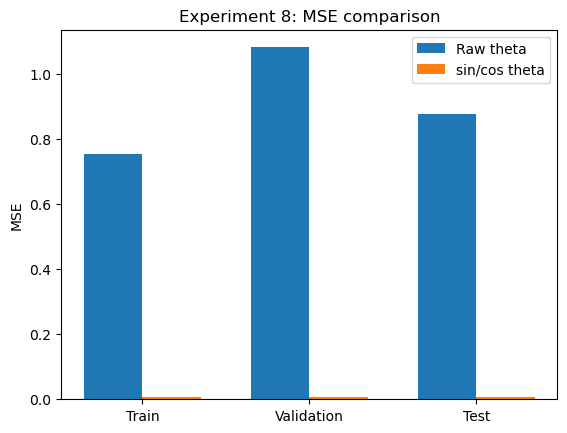

In [33]:
split_names = ["Train", "Validation", "Test"]

raw_mse_values = [
    raw_train_mse,
    raw_val_mse,
    raw_test_mse,
]

periodic_mse_values = [
    periodic_train_mse,
    periodic_val_mse,
    periodic_test_mse,
]

positions = np.arange(len(split_names))
width = 0.35

fig, ax = plt.subplots()

ax.bar(positions - width / 2, raw_mse_values, width, label="Raw theta")
ax.bar(positions + width / 2, periodic_mse_values, width, label="sin/cos theta")

ax.set_xticks(positions)
ax.set_xticklabels(split_names)

ax.set_ylabel("MSE")
ax.set_title("Experiment 8: MSE comparison")
ax.legend()

fig_path = FIGURE_DIR / "exp8_mse_comparison.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp8_prediction_vs_truth.png


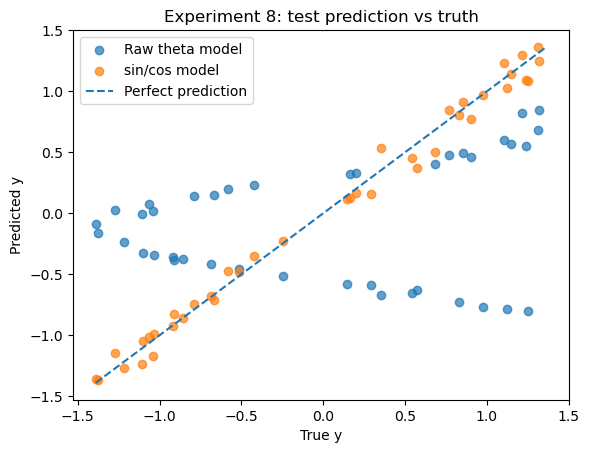

In [35]:
fig, ax = plt.subplots()

ax.scatter(y_test, y_pred_raw_test, label="Raw theta model", alpha=0.7)
ax.scatter(y_test, y_pred_periodic_test, label="sin/cos model", alpha=0.7)

min_value = min(y_test.min(), y_pred_raw_test.min(), y_pred_periodic_test.min())
max_value = max(y_test.max(), y_pred_raw_test.max(), y_pred_periodic_test.max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

ax.set_xlabel("True y")
ax.set_ylabel("Predicted y")
ax.set_title("Experiment 8: test prediction vs truth")
ax.legend()

fig_path = FIGURE_DIR / "exp8_prediction_vs_truth.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()